In [1]:
from bh_agent_model.analysis.bh_hierarchical_model.bh_hierarchical_model import BHHierarchicalModel
from bh_agent_model.utils.base.agents import fundamentalist, chartist, contrarian, optimist
from bh_agent_model.utils.base.markets import Market

import numpy as np
import matplotlib.pyplot as plt

import pytensor
import pymc as pm
import arviz as az

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [3]:
# generate synthetic market data
traders = [
        fundamentalist(),
        chartist(g=1.05),
        contrarian(g=-0.7),
        optimist(b=0.003)
    ]
market = Market(
    traders=traders,
    beta=1.5,
    r=1.01,
    sigma2=0.25,
    risk_aversion=5.0,
    noise_std=0.01,
)

T = 100
prices = []
weights_history = []

for _ in range(T):
    x, w = market.step()
    prices.append(x)
    weights_history.append(w)

prices = np.array(prices)
prices_std = (prices - prices.mean()) / prices.std()
weights_history = np.array(weights_history)

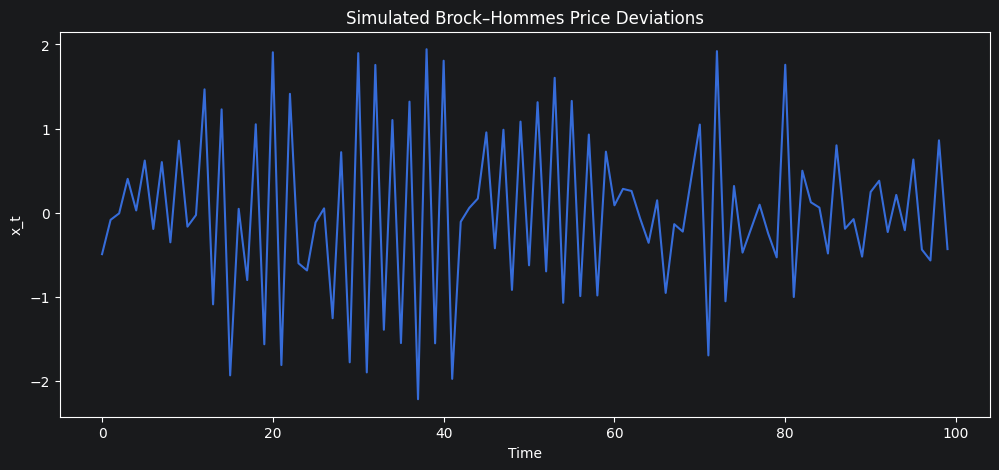

In [4]:
# visualize simulated prices
plt.figure(figsize=(12, 5))

plt.plot(prices_std)

plt.title("Simulated Brock–Hommes Price Deviations")
plt.xlabel("Time")
plt.ylabel("x_t")

plt.show()

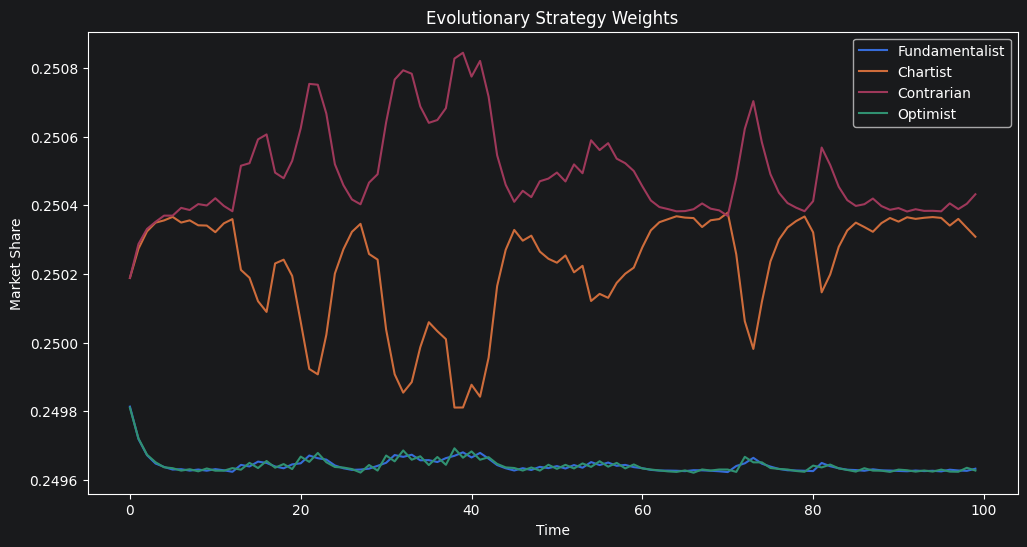

In [5]:
# visualize evolutionary market shares
labels = [
    "Fundamentalist",
    "Chartist",
    "Contrarian",
    "Optimist",
]

plt.figure(figsize=(12, 6))

for i in range(weights_history.shape[1]):

    plt.plot(
        weights_history[:, i],
        label=labels[i]
    )

plt.legend()

plt.title("Evolutionary Strategy Weights")
plt.xlabel("Time")
plt.ylabel("Market Share")

plt.show()

In [6]:
# bayesian hierarchical model
bh_model = BHHierarchicalModel(observed_prices = prices_std, n_traders=len(traders))
model = bh_model.build()

In [7]:
# run mcmc inference
with model:
    trace = pm.sample(
        draws=200,
        tune=200,
        chains=2,
        target_accept=0.95,
        return_inferencedata=True,
    )

Only 200 samples in chain.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [mu_g, sigma_g, mu_b, sigma_b, g, b, obs_sigma]


<div><progress max="800" value="800"></progress> 100.00% [800/800 01:50&lt;00:00... Sampling 2 chains, 1 divergences]</div>

Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 110 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [17]:
# posterior summary
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_g,0.616,0.395,0.248,1.227,0.258,0.018,3.0,34.0,1.97
mu_b,-0.095,0.103,-0.193,0.057,0.068,0.002,3.0,11.0,1.93
b[0],-0.505,0.513,-1.015,0.093,0.354,0.004,3.0,30.0,2.25
b[1],0.145,0.145,-0.062,0.282,0.096,0.004,3.0,12.0,1.83
b[2],-0.548,0.553,-1.096,0.094,0.381,0.005,3.0,17.0,1.87
b[3],-0.484,0.487,-0.967,0.063,0.336,0.005,3.0,31.0,1.85
sigma_g,0.311,0.209,0.013,0.512,0.140,0.008,3.0,12.0,2.02
sigma_b,0.110,0.054,0.003,0.161,0.025,0.011,8.0,69.0,1.88
g[0],0.246,0.639,-0.389,0.991,0.441,0.006,3.0,11.0,2.07
g[1],0.529,0.362,0.173,0.989,0.248,0.006,3.0,132.0,1.85


array([[<Axes: title={'center': 'mu_g'}>,
        <Axes: title={'center': 'mu_g'}>],
       [<Axes: title={'center': 'mu_b'}>,
        <Axes: title={'center': 'mu_b'}>],
       [<Axes: title={'center': 'b'}>, <Axes: title={'center': 'b'}>],
       [<Axes: title={'center': 'sigma_g'}>,
        <Axes: title={'center': 'sigma_g'}>],
       [<Axes: title={'center': 'sigma_b'}>,
        <Axes: title={'center': 'sigma_b'}>],
       [<Axes: title={'center': 'g'}>, <Axes: title={'center': 'g'}>],
       [<Axes: title={'center': 'obs_sigma'}>,
        <Axes: title={'center': 'obs_sigma'}>]], dtype=object)

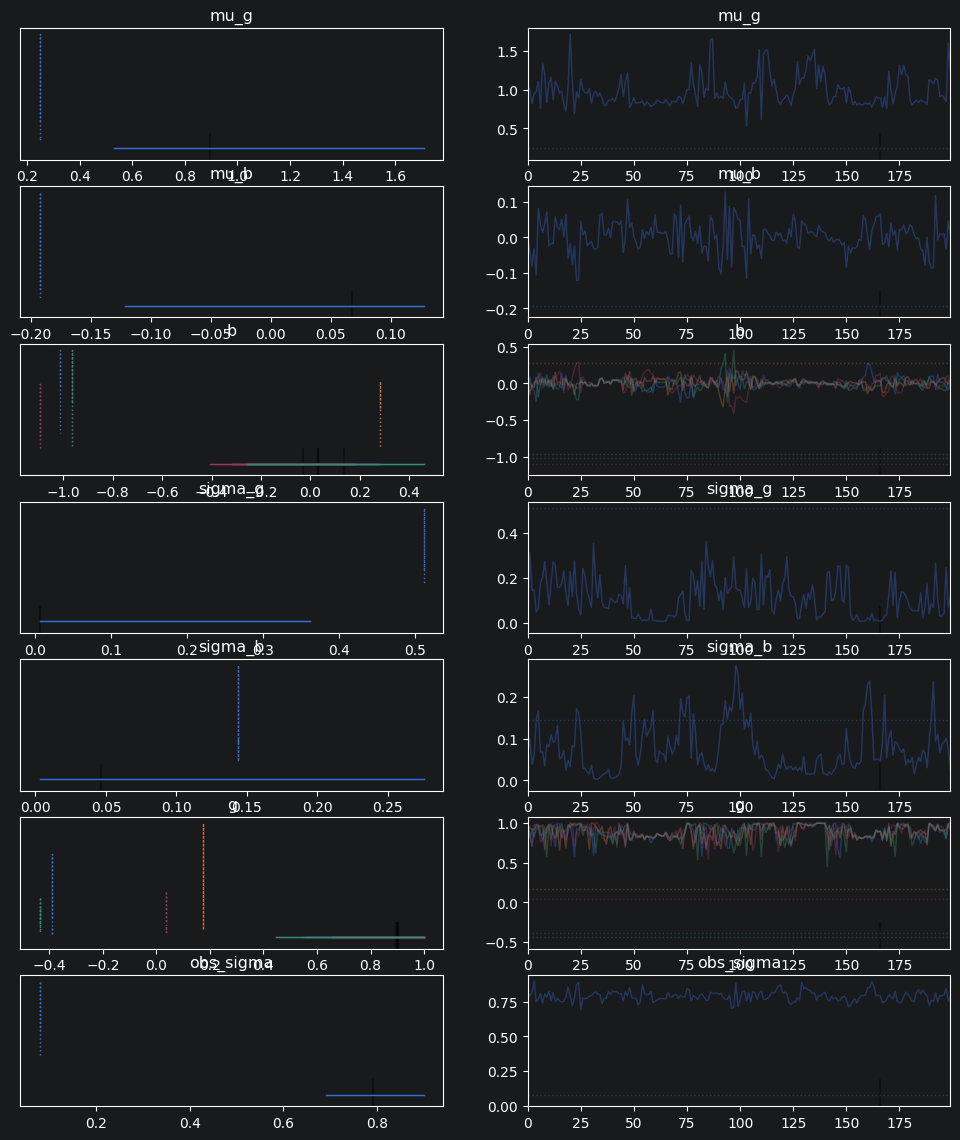

In [10]:
# trace diagnostics
az.plot_trace(data=trace)

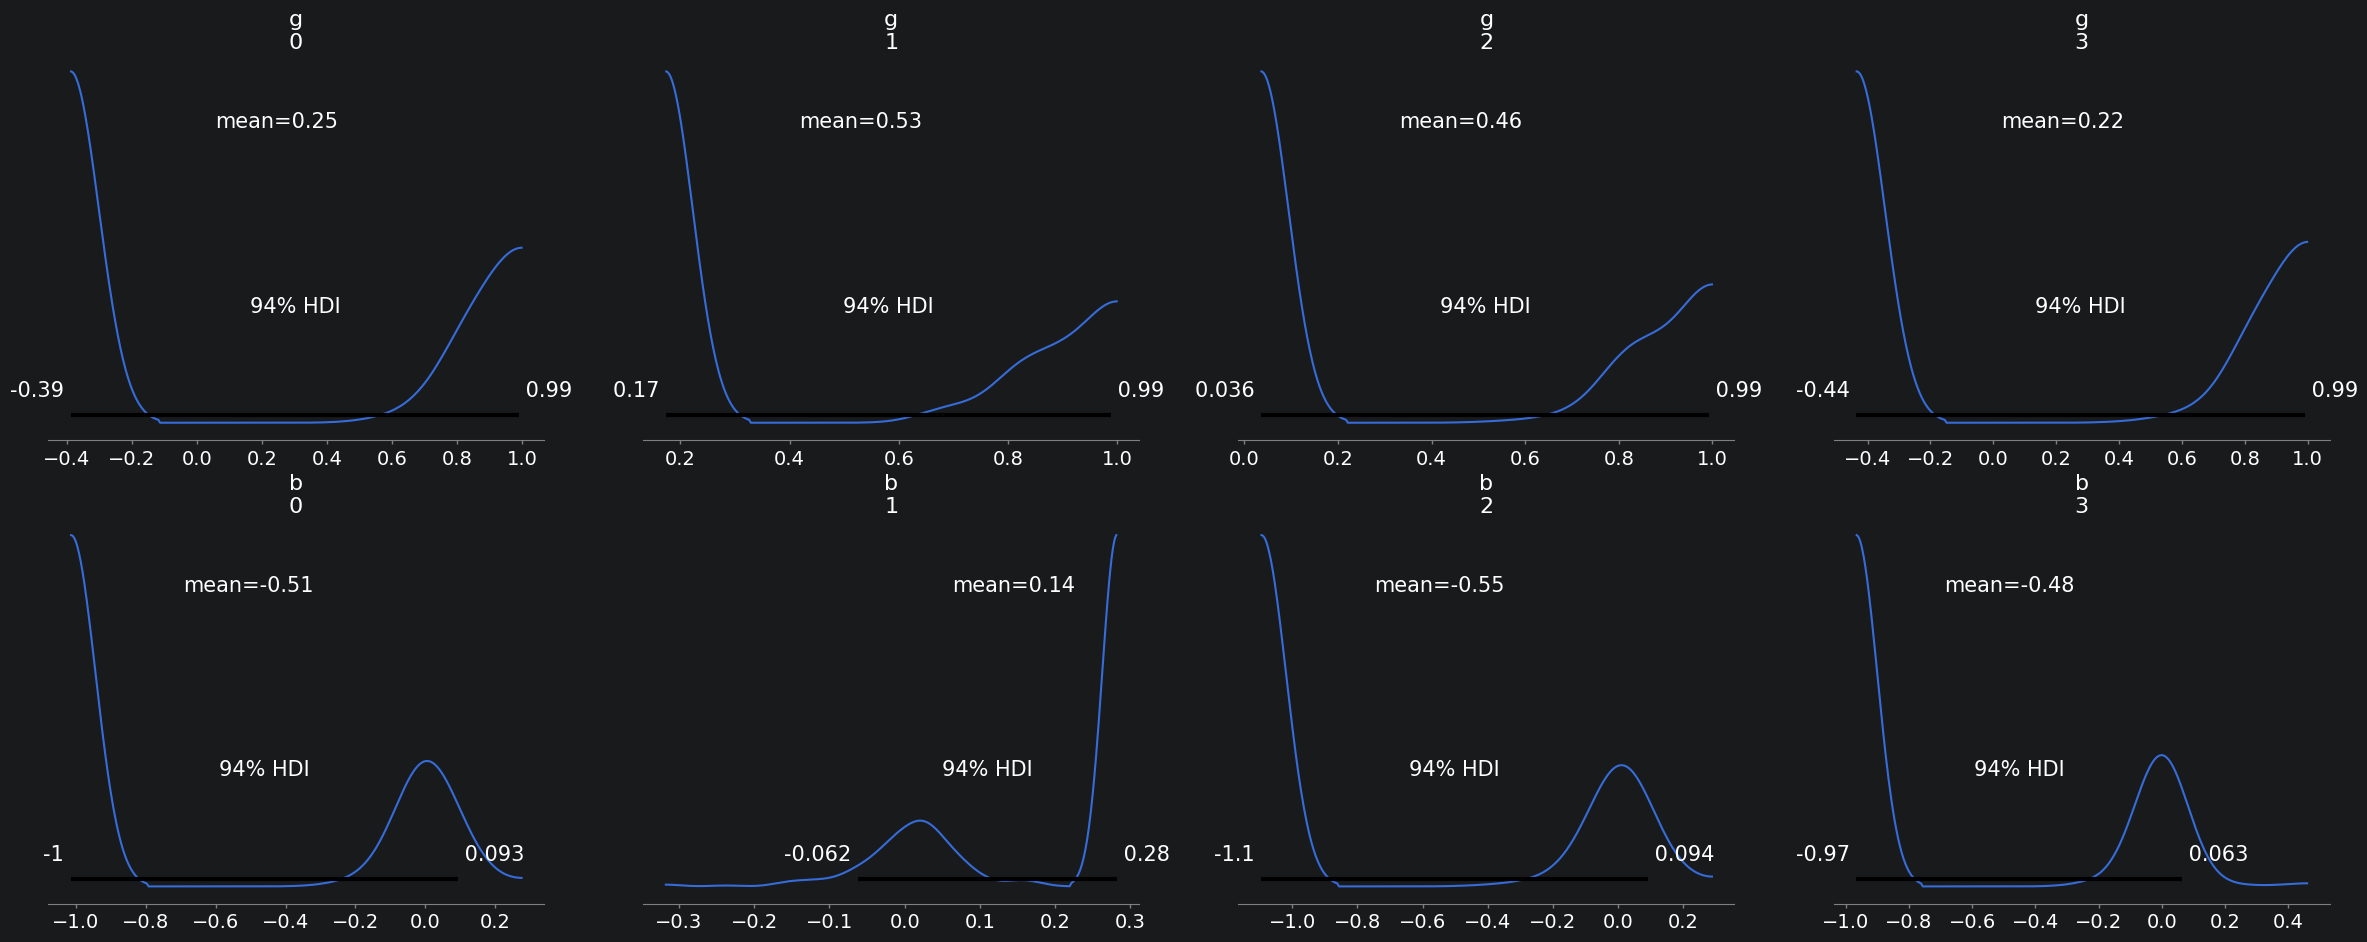

In [11]:
# posterior distributions of trader parameters
az.plot_posterior(data=trace, var_names=["g","b"])
plt.show()

In [12]:
# posterior predictive checks
with model:
    ppc = pm.sample_posterior_predictive(trace=trace)

Sampling: [x_obs]


<div><progress max="400" value="400"></progress> 100.00% [400/400 00:00&lt;00:00]</div>

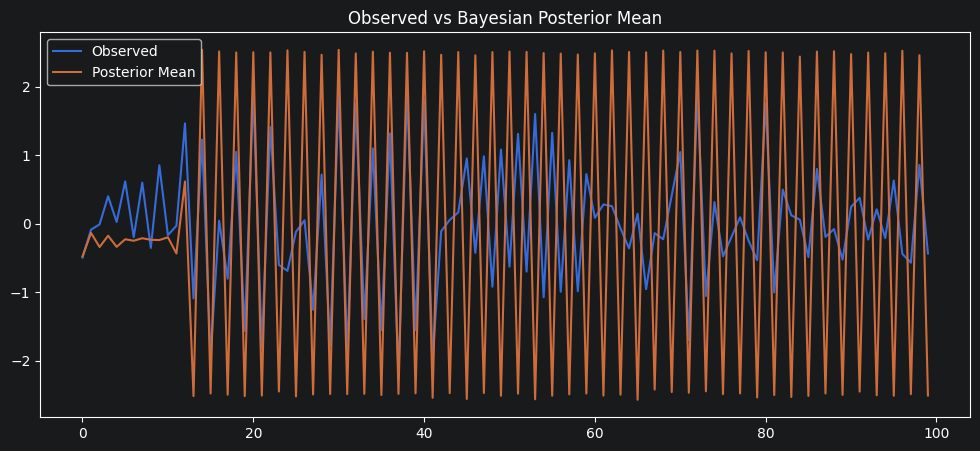

In [13]:
# compare simulated vs fitted prices
posterior_mean = (
    ppc.posterior_predictive["x_obs"].mean(dim=["chain","draw"]).values
)

plt.figure(figsize=(12, 5))

plt.plot(prices_std, label="Observed")
plt.plot(posterior_mean, label="Posterior Mean")

plt.legend()

plt.title("Observed vs Bayesian Posterior Mean")

plt.show()